In [1]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
os.environ['GROQ_API_KEY']=os.getenv('GROQ_API_KEY')

In [3]:
from langchain_groq import ChatGroq
model=ChatGroq(model="openai/gpt-oss-20b")
result=model.invoke("hey")
result.content

'Hey! How can I help you today?'

In [4]:
from pydantic import BaseModel
from typing_extensions import TypedDict
from langgraph.graph import START, END, StateGraph
from langgraph.graph import MessagesState
from langgraph.checkpoint.memory import MemorySaver
from langgraph.prebuilt import tools_condition, ToolNode
from langchain_core.messages import AIMessage, HumanMessage, SystemMessage
from IPython.display import display,Image

In [5]:
def multi(a:int,b:int)->int:
    """Multiply a and b.
    
        Args:
            a: first int
            b: second int
        """
    return a*b

def add(a:int,b:int)->int:
    """Adds a and b.
    
        Args:
            a: first int
            b: second int
        """
    return a+b


def sub(a:int,b:int)->float:
    """Subtract a from b.
    
        Args:
            a: first int
            b: second int
        """
    return a-b

In [6]:
tools=[multi,add,sub]

In [7]:
model_tool=model.bind_tools(tools)

In [8]:
result=model_tool.invoke("add 2 and 4 and multiply the result with 7")
result.tool_calls

[{'name': 'add',
  'args': {'a': 2, 'b': 4},
  'id': 'fc_362fdf88-da42-4f0e-b1ff-3c1076d6bb71',
  'type': 'tool_call'}]

In [9]:
sys_msg = SystemMessage(content="You are a helpful assistant tasked with performing arithmetic on a set of inputs.")

def assistant(state:MessagesState):
    return {"messages": [model_tool.invoke([sys_msg] + state["messages"])]}


def humanfeedback(state:MessagesState):
    pass

In [10]:
graph=StateGraph(MessagesState)
graph.add_node("assistant",assistant)
graph.add_node("tools",ToolNode(tools))
graph.add_edge(START,"human")
graph.add_conditional_edges("assistant",tools_condition)
graph.add_node("human",humanfeedback)
graph.add_edge("human", "assistant")
graph.add_edge("tools","human")

graph.add_edge("assistant",END)
memory=MemorySaver()
react=graph.compile(interrupt_before=["assistant"], checkpointer=memory)

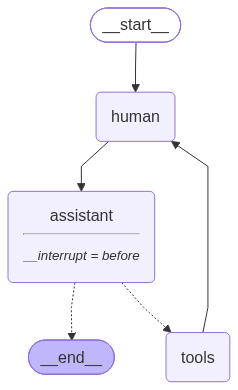

In [11]:
display(Image(react.get_graph().draw_mermaid_png()))

In [12]:
# Input
initial_input = {"messages": "Multiply 2 and 3"}

# Thread
thread = {"configurable": {"thread_id": "5"}}

# Run the graph until the first interruption
for event in react.stream(initial_input, thread, stream_mode="values"):
    event["messages"][-1].pretty_print()
    
    
    
    
    




================================ Human Message =================================

Multiply 2 and 3


In [13]:
for event in react.stream(None, thread, stream_mode="values"):
    event["messages"][-1].pretty_print()

================================ Human Message =================================

Multiply 2 and 3
================================== Ai Message ==================================
Tool Calls:
  multi (fc_92095e43-5027-40bb-9a22-f6d08158ea37)
 Call ID: fc_92095e43-5027-40bb-9a22-f6d08158ea37
  Args:
    a: 2
    b: 3
================================= Tool Message =================================
Name: multi

6


In [14]:
## get user input

user_input=input("Tell me how you want to update the state:")

react.update_state(thread,{"messages":user_input},as_node="human")

# Continue the graph execution
for event in react.stream(None, thread, stream_mode="values"):
    event["messages"][-1].pretty_print()

================================ Human Message =================================


================================== Ai Message ==================================

The product of 2 and 3 is **6**.


In [15]:
initial_input={"messages":HumanMessage(content="Multiply 2 and 3")}

thread = {"configurable": {"thread_id": "8"}}

In [16]:
for event in react.stream(initial_input,thread,stream_mode="values"):
    event['messages'][-1].pretty_print()

================================ Human Message =================================

Multiply 2 and 3


In [17]:
for event in react.stream(None,thread,stream_mode="values"):
    event['messages'][-1].pretty_print()

================================ Human Message =================================

Multiply 2 and 3


================================== Ai Message ==================================
Tool Calls:
  multi (fc_e296a5b5-ad15-438a-befa-21f989f7ca1a)
 Call ID: fc_e296a5b5-ad15-438a-befa-21f989f7ca1a
  Args:
    a: 2
    b: 3
================================= Tool Message =================================
Name: multi

6


In [18]:
thread = {"configurable": {"thread_id": "11"}}

input={"messages":HumanMessage(content=("multiply 5 and 6"))}

In [20]:
for event in react.stream(input,thread,stream_mode="values"):
    
    event['messages'][-1].pretty_print()

================================ Human Message =================================

multiply 5 and 6


In [21]:
for event in react.stream(None,thread,stream_mode="values"):
    
    event['messages'][-1].pretty_print()

================================ Human Message =================================

multiply 5 and 6
================================== Ai Message ==================================
Tool Calls:
  multi (fc_3cb57092-d460-47b1-a617-ad7ae30ccc61)
 Call ID: fc_3cb57092-d460-47b1-a617-ad7ae30ccc61
  Args:
    a: 5
    b: 6
================================= Tool Message =================================
Name: multi

30


In [23]:
react.update_state(thread,{"messages":HumanMessage(content="instead of multipylting add these number 5 and 6")})

{'configurable': {'thread_id': '11',
  'checkpoint_ns': '',
  'checkpoint_id': '1f1a36de-8f4b-6b0b-8007-cdd27b82596e'}}

In [25]:
new_state = react.get_state(thread).values
for m in new_state['messages']:
    m.pretty_print()
    

================================ Human Message =================================

multiply 5 and 6
================================== Ai Message ==================================
Tool Calls:
  multi (fc_3cb57092-d460-47b1-a617-ad7ae30ccc61)
 Call ID: fc_3cb57092-d460-47b1-a617-ad7ae30ccc61
  Args:
    a: 5
    b: 6
================================= Tool Message =================================
Name: multi

30
================================ Human Message =================================

instead of multipylting add these number 5 and 6


In [27]:
for event in react.stream(None, thread, stream_mode="values"):
    event['messages'][-1].pretty_print()


================================ Human Message =================================

instead of multipylting add these number 5 and 6
================================== Ai Message ==================================
Tool Calls:
  add (fc_bf8570ea-9208-4e00-a93f-bc3314091205)
 Call ID: fc_bf8570ea-9208-4e00-a93f-bc3314091205
  Args:
    a: 5
    b: 6
================================= Tool Message =================================
Name: add

11
